<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/RNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health


In [ ]:
# ------------------------------------------
# Import Libraries
# ------------------------------------------

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# ------------------------------------------
# Check Files Inside Dataset Folder
# ------------------------------------------

print("\nFiles in Dataset Folder:")
print(os.listdir(path))


Files in Dataset Folder:
['Combined Data.csv']


In [ ]:
# ------------------------------------------
# Load CSV File
# ------------------------------------------

# Replace filename if needed after checking files
file_path = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(file_path)

In [ ]:
# ------------------------------------------
# Display Dataset
# ------------------------------------------

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

Dataset Shape:
(53043, 3)

Column Names:
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

Missing Values:
Unnamed: 0      0
statement     362
status          0
dtype: int64


In [ ]:
# ------------------------------------------
# Column Names
# ------------------------------------------

text_col = "statement"
label_col = "status"

In [ ]:
# ------------------------------------------
# Number of Sentiment Classes
# ------------------------------------------

print("\n========== Sentiment Classes ==========")

num_classes = df[label_col].nunique()

print("Number of Classes:", num_classes)

print("\nClass Names:")
print(df[label_col].unique())


========== Sentiment Classes ==========
Number of Classes: 7

Class Names:
['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']



========== Text Distribution ==========
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


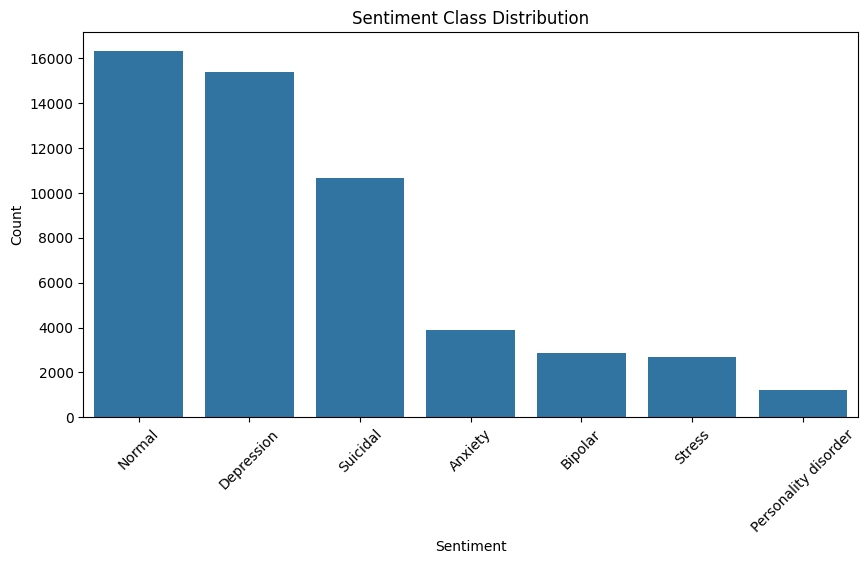

In [ ]:
# ------------------------------------------
# Text Distribution
# ------------------------------------------

print("\n========== Text Distribution ==========")

class_counts = df[label_col].value_counts()

print(class_counts)

# Plot Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    x=df[label_col],
    order=class_counts.index
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()



========== Class Imbalance ==========
status
Normal                  30.825934
Depression              29.040590
Suicidal                20.083706
Anxiety                  7.329902
Bipolar                  5.423901
Stress                   5.031767
Personality disorder     2.264201
Name: count, dtype: float64


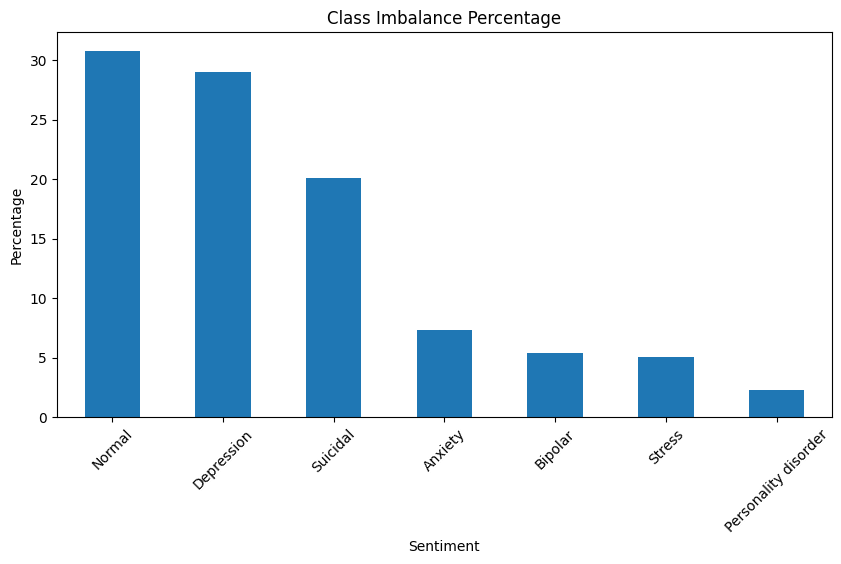

In [ ]:
# ------------------------------------------
# Class Imbalance
# ------------------------------------------

print("\n========== Class Imbalance ==========")

class_percentage = (class_counts / len(df)) * 100

print(class_percentage)

# Plot Class Imbalance
plt.figure(figsize=(10,5))

class_percentage.plot(
    kind='bar'
)

plt.title("Class Imbalance Percentage")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.show()



========== Sentence Length Analysis ==========
Average Sentence Length: 112.39 words

Sentence Length Statistics:
count    53043.000000
mean       112.393285
std        163.436684
min          1.000000
25%         15.000000
50%         61.000000
75%        147.500000
max       6300.000000
Name: sentence_length, dtype: float64


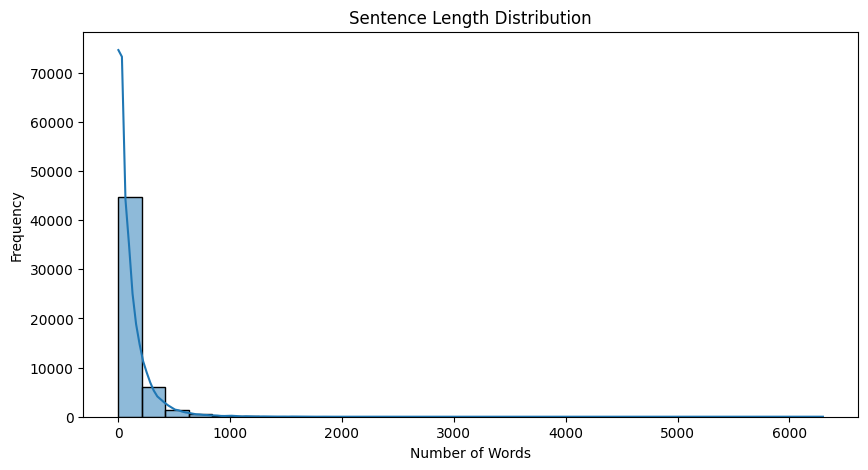

In [ ]:
# ------------------------------------------
# Average Sentence Length
# ------------------------------------------

print("\n========== Sentence Length Analysis ==========")

# Count words
df["sentence_length"] = df[text_col].apply(
    lambda x: len(str(x).split())
)

# Average length
avg_length = df["sentence_length"].mean()

print("Average Sentence Length:",
      round(avg_length, 2),
      "words")

# Statistics
print("\nSentence Length Statistics:")
print(df["sentence_length"].describe())

# Plot Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df["sentence_length"],
    bins=30,
    kde=True
)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()


In [ ]:
# ------------------------------------------
# Final Summary
# ------------------------------------------

print("\n========== DATASET SUMMARY ==========")

print("Total Records:", len(df))
print("Number of Sentiment Classes:", num_classes)
print("Average Sentence Length:",
      round(avg_length, 2),
      "words")

print("====================================")


========== DATASET SUMMARY ==========
Total Records: 53043
Number of Sentiment Classes: 7
Average Sentence Length: 112.39 words


In [ ]:
# ==========================================
# Task 2 — Text Preprocessing
# Mental Health Sentiment Analysis
# ==========================================

# ------------------------------------------
# Import Libraries
# ------------------------------------------

import kagglehub
import pandas as pd
import numpy as np
import re
import string
import os

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [ ]:
# ------------------------------------------
# Download NLTK Resources
# ------------------------------------------

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
nltk.download('punkt_tab')

In [ ]:
file_path = os.path.join(path, "Combined Data.csv")

df = pd.read_csv(file_path)

In [ ]:
# ------------------------------------------
# Select Required Columns
# ------------------------------------------

text_col = "statement"
label_col = "status"

# Keep only needed columns
df = df[[text_col, label_col]]

# Remove missing values
df.dropna(inplace=True)


In [ ]:
# ------------------------------------------
# Stopwords
# ------------------------------------------

stop_words = set(stopwords.words('english'))

In [ ]:
# ------------------------------------------
# Text Cleaning Function
# ------------------------------------------

def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", "", text)

    # Tokenization
    words = word_tokenize(text)

    # Stopword removal
    words = [word for word in words if word not in stop_words]

    # Join words back
    cleaned_text = " ".join(words)

    return cleaned_text




In [ ]:
# ------------------------------------------
# Apply Preprocessing
# ------------------------------------------
nltk.download('punkt_tab')
df["cleaned_text"] = df[text_col].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# ------------------------------------------
# Display Sample
# ------------------------------------------

print("\n========== ORIGINAL TEXT ==========")
print(df[text_col].iloc[0])

print("\n========== CLEANED TEXT ==========")
print(df["cleaned_text"].iloc[0])



========== ORIGINAL TEXT ==========
oh my gosh

========== CLEANED TEXT ==========
oh gosh


In [ ]:
# ------------------------------------------
# Vocabulary Generation
# ------------------------------------------

max_vocab_size = 10000

tokenizer = Tokenizer(num_words=max_vocab_size)

tokenizer.fit_on_texts(df["cleaned_text"])

# Word Index
word_index = tokenizer.word_index

print("\nVocabulary Size:",
      len(word_index))


Vocabulary Size: 79570


In [ ]:
# ------------------------------------------
# Convert Text to Sequences
# ------------------------------------------

sequences = tokenizer.texts_to_sequences(
    df["cleaned_text"]
)

print("\nSample Sequence:")
print(sequences[0])


Sample Sequence:
[486, 4641]


In [ ]:
# ------------------------------------------
# Padding
# ------------------------------------------

max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("\nPadded Sequence Shape:")
print(padded_sequences.shape)

print("\nSample Padded Sequence:")
print(padded_sequences[0])



Padded Sequence Shape:
(52681, 50)

Sample Padded Sequence:
[ 486 4641    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [ ]:
# ------------------------------------------
# Final Output Summary
# ------------------------------------------

print("\n========== PREPROCESSING SUMMARY ==========")

print("Lowercase Conversion      : Done")
print("Punctuation Removal      : Done")
print("Stopword Removal         : Done")
print("Tokenization             : Done")
print("Vocabulary Generation    : Done")
print("Padding                  : Done")

print("\nMaximum Vocabulary Size :", max_vocab_size)
print("Maximum Sentence Length :", max_length)

print("===========================================")


========== PREPROCESSING SUMMARY ==========
Lowercase Conversion      : Done
Punctuation Removal      : Done
Stopword Removal         : Done
Tokenization             : Done
Vocabulary Generation    : Done
Padding                  : Done

Maximum Vocabulary Size : 10000
Maximum Sentence Length : 50


# Task3

In [ ]:
# ==========================================
# 1. Tokenizer
# ==========================================

# Create tokenizer object
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

# Learn all words from dataset
tokenizer.fit_on_texts(df["cleaned_text"])

print("\nTokenizer Created Successfully")


Tokenizer Created Successfully


In [ ]:
# ==========================================
# 2. Word Indexing
# ==========================================

# Create word-to-number mapping
word_index = tokenizer.word_index

print("\nTotal Unique Words:")
print(len(word_index))

# Show first 10 word indexes
print("\nFirst 10 Word Indexes:")

for word, index in list(word_index.items())[:10]:
    print(word, ":", index)


Total Unique Words:
79570

First 10 Word Indexes:
like : 1
feel : 2
want : 3
’ : 4
know : 5
life : 6
get : 7
even : 8
time : 9
would : 10


In [ ]:
# ==========================================
# 3. Convert Text to Numerical Sequences
# ==========================================

sequences = tokenizer.texts_to_sequences(df["cleaned_text"])

print("\nSample Numerical Sequence:")
print(sequences[0])


Sample Numerical Sequence:
[486, 4641]


In [ ]:
# ==========================================
# 4. Padded Sequences
# ==========================================

max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("\nPadded Sequence Shape:")
print(padded_sequences.shape)

print("\nSample Padded Sequence:")
print(padded_sequences[0])


Padded Sequence Shape:
(52681, 50)

Sample Padded Sequence:
[ 486 4641    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [ ]:
# ==========================================
# Final Summary
# ==========================================

print("\n========== SEQUENCE PREPARATION SUMMARY ==========")

print("Tokenizer Applied                : Done")
print("Word Indexing Completed          : Done")
print("Text Converted to Sequences      : Done")
print("Padding Applied                  : Done")

print("\nVocabulary Size :", vocab_size)
print("Maximum Sequence Length :", max_length)


========== SEQUENCE PREPARATION SUMMARY ==========
Tokenizer Applied                : Done
Word Indexing Completed          : Done
Text Converted to Sequences      : Done
Padding Applied                  : Done

Vocabulary Size : 10000
Maximum Sequence Length : 50


Why RNN Cannot Directly Understand Raw Text
1. RNN Works Only With Numbers

A Simple RNN is a mathematical neural network model.

It performs:

matrix multiplication
addition
activation functions

These operations can only be done on numerical values, not on words or sentences.

Example:

Raw text:

I feel happy today

RNN cannot process words like:

"I"
"feel"
"happy"

because they are strings (text data), not numbers.

2. Text Must Be Converted Into Numerical Form

Before giving text to RNN:

each word is converted into a unique number.

Example:

Word	Index
i	1
feel	2
happy	3
today	4

Sentence becomes:

[1, 2, 3, 4]

Now RNN can process it.

3. Sentences Have Different Lengths

Example:

Sentence 1:

I am sad

Sentence 2:

I am feeling very happy today

Neural networks require equal-sized inputs.

So we use:

padding
to make all sequences the same length.

Example:

[1, 2, 3, 0, 0]
[1, 2, 4, 5, 6]
4. Tokenizer Helps Build Vocabulary

Tokenizer:

identifies all words
creates vocabulary
assigns indexes
converts text to sequences

Without tokenizer:

RNN cannot understand word positions or meanings.
Complete Flow
Raw Text
   ↓
Cleaning
   ↓
Tokenizer
   ↓
Word Indexing
   ↓
Numerical Sequences
   ↓
Padding
   ↓
RNN Model
Simple Conclusion

RNN cannot directly understand raw text because:

neural networks only understand numbers
text data must be converted into numerical sequences
all input sequences must have equal length

Therefore:

Tokenizer
word indexing
padded sequences

are necessary before training an RNN model.

In [ ]:
# ==========================================
# Task 4 — Build Simple RNN Architecture
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Build Model
model = Sequential()

# 1. Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# 2. SimpleRNN Layer
model.add(
    SimpleRNN(
        units=64,
        activation='tanh'
    )
)

# 3. Dense Output Layer
model.add(
    Dense(
        units=len(df[label_col].unique()),
        activation='softmax'
    )
)

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# Task 5 — Model Training
# ==========================================

from tensorflow.keras.optimizers import Adam

# ------------------------------------------
# Learning Rate Tuning
# ------------------------------------------

learning_rate = 0.001

optimizer = Adam(learning_rate=learning_rate)

# Recompile model with tuned learning rate
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ------------------------------------------
# Training Parameters
# ------------------------------------------

batch_size = 32
epochs = 10

In [ ]:
# ------------------------------------------
# Train Model
# ------------------------------------------

from sklearn.preprocessing import LabelEncoder

# Prepare training data (X)
X = padded_sequences

# Prepare target labels (y)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[label_col])

history = model.fit(
    X,                      # training data
    y,                      # target labels
    validation_split=0.2,  # 20% validation data
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.5373 - loss: 1.0996 - val_accuracy: 0.3471 - val_loss: 3.8850
Epoch 2/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.6277 - loss: 0.8400 - val_accuracy: 0.3291 - val_loss: 4.0132
Epoch 3/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.6491 - loss: 0.7978 - val_accuracy: 0.3893 - val_loss: 3.4332
Epoch 4/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.6964 - loss: 0.6505 - val_accuracy: 0.4000 - val_loss: 4.1848
Epoch 5/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.7434 - loss: 0.5548 - val_accuracy: 0.3866 - val_loss: 4.3818
Epoch 6/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 0.7792 - loss: 0.5039 - val_accuracy: 0.3735 - val_loss: 4.6336
Epoch 7/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.8140 - loss: 0.4535 - val_accuracy: 0.3843 - val_loss: 4.8869
Epoch 8/10
1317/1317 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.8501 -

In [ ]:
# ------------------------------------------
# Training Complete
# ------------------------------------------

print("\n========== TRAINING COMPLETED ==========")

print("Batch Size      :", batch_size)
print("Epochs          :", epochs)
print("Learning Rate   :", learning_rate)
print("Validation Split: 20%")

print("========================================")


========== TRAINING COMPLETED ==========
Batch Size      : 32
Epochs          : 10
Learning Rate   : 0.001
Validation Split: 20%


In [ ]:
# ==========================================
# Task 6 — Model Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ------------------------------------------
# Predict Classes
# ------------------------------------------

y_pred_probs = model.predict(X)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

1647/1647 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step


In [ ]:
# ------------------------------------------
# Accuracy
# ------------------------------------------

accuracy = accuracy_score(y, y_pred)

print("\nAccuracy:")
print(round(accuracy, 4))


Accuracy:
0.7589


In [ ]:
# ------------------------------------------
# Precision
# ------------------------------------------

precision = precision_score(
    y,
    y_pred,
    average='weighted'
)

print("\nPrecision:")
print(round(precision, 4))


Precision:
0.7006


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ------------------------------------------
# Recall
# ------------------------------------------

recall = recall_score(
    y,
    y_pred,
    average='weighted'
)

print("\nRecall:")
print(round(recall, 4))

In [ ]:
# ------------------------------------------
# F1 Score
# ------------------------------------------

f1 = f1_score(
    y,
    y_pred,
    average='weighted'
)

print("\nF1 Score:")
print(round(f1, 4))



F1 Score:
0.7261


In [ ]:
# ------------------------------------------
# Classification Report
# ------------------------------------------

print("\n========== Classification Report ==========")

print(
    classification_report(
        y,
        y_pred
    )
)


========== Classification Report ==========
              precision    recall  f1-score   support

           0       0.69      0.52      0.59      3841
           1       0.00      0.00      0.00      2777
           2       0.76      0.79      0.77     15404
           3       0.85      0.94      0.89     16343
           4       0.00      0.00      0.00      1077
           5       0.39      0.37      0.38      2587
           6       0.72      0.89      0.80     10652

    accuracy                           0.76     52681
   macro avg       0.49      0.50      0.49     52681
weighted avg       0.70      0.76      0.73     52681



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[ 1982     0   693   496     0   516   154]
 [  391     0  1213   394     0   371   408]
 [  167     0 12163   529     0   296  2249]
 [   27     0   317 15376     0   151   472]
 [   98     0   442   199     0   147   191]
 [  186     1   643   535     0   964   258]
 [    6     0   550   543     0    56  9497]]


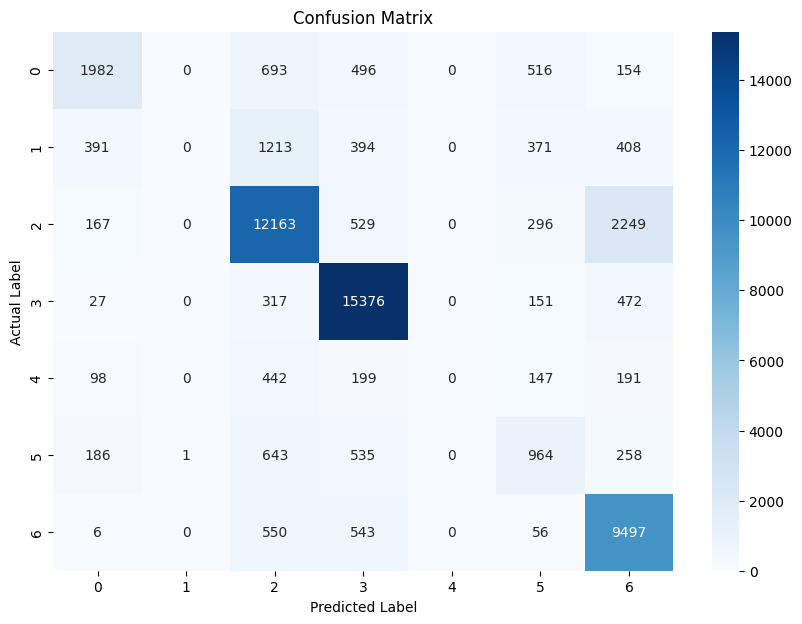

In [ ]:
# ------------------------------------------
# Plot Confusion Matrix
# ------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


In [ ]:
recall = recall_score(
    y,
    y_pred,
    average='weighted'
)

# ------------------------------------------
# Final Summary
# ------------------------------------------

print("\n========== MODEL EVALUATION SUMMARY ==========")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


========== MODEL EVALUATION SUMMARY ==========
Accuracy : 0.7589
Precision: 0.7006
Recall   : 0.7589
F1 Score : 0.7261


Task 7 — Sequence Understanding
1. How RNN Remembers Previous Words

A Recurrent Neural Network (RNN) processes text one word at a time in sequence.

Unlike normal neural networks, an RNN has a memory mechanism that stores information from previous words.

Example sentence:

"I am feeling very sad today"

RNN reads the sentence step-by-step:

"I" → "am" → "feeling" → "very" → "sad" → "today"

When processing the current word, the RNN also keeps information about:

previous words
previous context
previous emotions

So while reading:

"sad"

the RNN already remembers:

"I am feeling very"

This helps the model understand the emotional meaning of the sentence.

2. Hidden State Concept

The hidden state is the internal memory of the RNN.

It stores important information learned from previous words.

At every time step:

current word enters the network
previous hidden state is combined with current input
new hidden state is generated

The hidden state acts like:

short-term memory
contextual understanding
sequence memory
Hidden State Flow
Previous Hidden State + Current Word
                  ↓
          RNN Computation
                  ↓
            New Hidden State
Simple Example

Sentence:

"I feel anxious"
Step 1:

Input:

"I"

Hidden state stores:

Information about "I"
Step 2:

Input:

"feel"

RNN uses:

current word = "feel"
previous hidden state = information about "I"

New hidden state stores:

"I feel"
Step 3:

Input:

"anxious"

RNN now remembers:

"I feel"

and combines it with:

"anxious"

Final understanding:

Negative emotional sentiment
3. Sequential Learning Behavior

RNN learns data in a sequence order.

This means:

word order matters
previous words affect future understanding

Example:

Sentence 1:

"I am happy"

Sentence 2:

"I am not happy"

Both sentences contain:

happy

But the word:

not

changes the entire meaning.

Because RNN reads sequentially, it understands:

context
order
relationships between words
Sequential Processing in RNN
Word 1 → Hidden State 1
               ↓
Word 2 → Hidden State 2
               ↓
Word 3 → Hidden State 3
               ↓
Final Prediction

Each hidden state carries information from previous steps.

Why Sequential Learning is Important

Sequential learning helps RNN:

understand sentence meaning
detect emotional patterns
learn context
analyze mental health sentiment
identify negative emotional trends

Example:

"I don't want to live anymore"

The emotional meaning depends on the full sequence, not individual words alone.

RNN captures this sequence behavior effectively.

Simple Conclusion
RNN Remembers Previous Words

Using hidden states that carry past information.

Hidden State

Acts as memory that stores context from earlier words.

Sequential Learning

RNN processes words in order, helping it understand:

meaning
emotions
context
sentiment patterns

This makes RNN very useful for:

sentiment analysis
mental health monitoring
chatbot systems
language processing tasks.


In [ ]:
# ==========================================
# Task 8 — Real-Time Prediction
# ==========================================

import numpy as np

# ------------------------------------------
# Function for Sentiment Prediction
# ------------------------------------------

def predict_sentiment(text):

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])

    # Padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # Predict probabilities
    prediction = model.predict(padded_sequence)

    # Predicted class index
    predicted_index = np.argmax(prediction)

    # Confidence score
    confidence_score = np.max(prediction)

    # Convert index to label
    predicted_label = encoder.inverse_transform(
        [predicted_index]
    )[0]

    # Display Result
    print("\n===================================")
    print("Input Text:")
    print(text)

    print("\nPredicted Emotion:")
    print(predicted_label)

    print("\nConfidence Score:")
    print(round(confidence_score * 100, 2), "%")
    print("===================================")

# ==========================================
# Test With Custom User Sentences
# ==========================================

predict_sentiment(
    "I feel very happy and motivated today"
)

predict_sentiment(
    "I am stressed and emotionally exhausted"
)

predict_sentiment(
    "Nobody understands me and I feel alone"
)

# ==========================================
# Test With Emotional Text Examples
# ==========================================

predict_sentiment(
    "Life is beautiful and I feel confident"
)

predict_sentiment(
    "I am anxious about my future"
)

predict_sentiment(
    "I don't want to talk to anyone anymore"
)

# ==========================================
# Test With Unseen Sentences
# ==========================================

predict_sentiment(
    "Everything feels meaningless lately"
)

predict_sentiment(
    "I finally achieved my goals and feel proud"
)

predict_sentiment(
    "Sometimes I feel emotionally numb"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Input Text:
I feel very happy and motivated today

Predicted Emotion:
Suicidal

Confidence Score:
70.8 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Input Text:
I am stressed and emotionally exhausted

Predicted Emotion:
Normal

Confidence Score:
54.26 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Input Text:
Nobody understands me and I feel alone

Predicted Emotion:
Suicidal

Confidence Score:
69.39 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Input Text:
Life is beautiful and I feel confident

Predicted Emotion:
Normal

Confidence Score:
42.11 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Input Text:
I am anxious about my future

Predicted Emotion:
Anxiety

Confidence Score:
89.92 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

Input Text:
I don't want to talk to anyone anymore

Predicted Emotion:
Suicidal

Confidence Score:
79.74 %
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Input Text:
Everything feels meaningless lately

Predicted Emotion:
Normal

Confidence Score:
48.2 %


In [ ]:
# ==========================================
# Task 9 — Save the Trained Model
# ==========================================

import pickle

# ------------------------------------------
# 1. Save Trained RNN Model
# ------------------------------------------

model.save("mental_health_rnn_model.h5")

print("RNN Model Saved Successfully")

# ------------------------------------------
# 2. Save Tokenizer
# ------------------------------------------

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer Saved Successfully")

# ------------------------------------------
# 3. Save Label Encoder
# ------------------------------------------

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

print("Label Encoder Saved Successfully")

# ------------------------------------------
# Final Message
# ------------------------------------------

print("\n========== FILES SAVED ==========")

print("1. mental_health_rnn_model.h5")
print("2. tokenizer.pkl")
print("3. label_encoder.pkl")

print("=================================")

RNN Model Saved Successfully
Tokenizer Saved Successfully
Label Encoder Saved Successfully

========== FILES SAVED ==========
1. mental_health_rnn_model.h5
2. tokenizer.pkl
3. label_encoder.pkl
